# **Pertemuan 2: Ekstraksi Fitur: Dari Tepi Hingga Deteksi Wajah**

**Tujuan Sesi:**  
Peserta belajar cara mengekstrak fitur penting dari citra seperti tepi dan bentuk, dan menggunakannya untuk mendeteksi objek kompleks seperti wajah.

## **Pengantar**

### **Konsep Konvolusi dan Deteksi Tepi**

Dalam pengolahan citra digital, **konvolusi** merupakan operasi penting yang memungkinkan kita untuk memanipulasi fitur visual dari gambar.  
Beberapa penerapannya antara lain:  
- **Blurring (reduksi noise)**: menggunakan kernel untuk meratakan nilai piksel di sekitarnya, sehingga detail halus dan noise berkurang.  
- **Sharpening**: meningkatkan kontras antar piksel agar tepi objek terlihat lebih tajam.  

Selanjutnya, kita akan mengenal **algoritma Canny Edge Detector**, salah satu metode paling populer untuk **menemukan garis batas objek** pada gambar.  
Metode ini bekerja dengan mendeteksi perubahan intensitas yang signifikan, lalu menandai area tersebut sebagai **tepi**.

## **Filter Spasial dan Deteksi Tepi**

**Konvolusi** adalah operasi matematika yang menggabungkan dua fungsi untuk menghasilkan fungsi ketiga. Dalam pengolahan citra, konvolusi digunakan untuk menerapkan **kernel** (matriks kecil) pada setiap piksel gambar.

**Jenis-jenis filter spatial:**
- **Gaussian Blur**: Mengurangi noise dengan meratakan nilai piksel
- **Sharpening**: Meningkatkan kontras tepi untuk membuat gambar lebih tajam
- **Edge Detection**: Mendeteksi perubahan intensitas yang signifikan (tepi objek)

**Canny Edge Detector** adalah algoritma deteksi tepi yang paling populer karena:
1. Mampu mendeteksi tepi dengan akurat
2. Menghasilkan tepi yang tipis (1 piksel)
3. Mengurangi noise dengan baik

> **Pertanyaan:** Apakah kamu sudah melakukan instalasi library `dlib`?

In [17]:
# Menyiapkan gambar yang dikirim user agar notebook bisa langsung dijalankan
import os, base64
os.makedirs('data', exist_ok=True)
_img_b64 = '...'
user_img_path = os.path.join(os.getcwd(), 'data', 'pria_solo.jpeg')
with open(user_img_path, 'wb') as f:
    f.write(base64.b64decode(_img_b64))
print('Gambar berhasil disiapkan di:', user_img_path)


Gambar berhasil disiapkan di: c:\Users\ASUS\Semester 6\Pengolahan Citra\Pengolahan_Multimedia\data\pria_solo.jpeg


In [18]:
# Import library yang dibutuhkan
import numpy as np  # Untuk operasi numerik dan manipulasi array
import matplotlib.pyplot as plt  # Untuk visualisasi gambar
import cv2  # OpenCV: library utama untuk pengolahan citra dan aplikasi terkait
import os  # Untuk operasi file dan path
# dlib sengaja tidak diimport agar notebook bisa jalan tanpa error 'No module named dlib'

# Cek versi library yang diinstal
print(f"Versi numpy: {np.__version__}")
print(f"Versi matplotlib: {plt.matplotlib.__version__}")
print(f"Versi OpenCV: {cv2.__version__}")
print("dlib: tidak digunakan pada versi modifikasi ini")

"""
📌 Catatan Penting:
Cara Instal Library
dlib → digunakan untuk deteksi wajah.
   - Instalasi di Windows bisa rumit.
   - Panduan lengkap: https://www.geeksforgeeks.org/python/how-to-install-dlib-library-for-python-in-windows-10/

💡 Disarankan menggunakan versi Python 3.10 atau 3.11 agar kompatibel.
"""

Versi numpy: 2.4.2
Versi matplotlib: 3.10.8
Versi OpenCV: 4.13.0
dlib: tidak digunakan pada versi modifikasi ini


'\n📌 Catatan Penting:\nCara Instal Library\ndlib → digunakan untuk deteksi wajah.\n   - Instalasi di Windows bisa rumit.\n   - Panduan lengkap: https://www.geeksforgeeks.org/python/how-to-install-dlib-library-for-python-in-windows-10/\n\n💡 Disarankan menggunakan versi Python 3.10 atau 3.11 agar kompatibel.\n'

In [19]:
# Panggil file
geo_img = user_img_path
img = cv2.imread(geo_img)

# Konversi ke RGB untuk ditampilkan dengan benar di matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

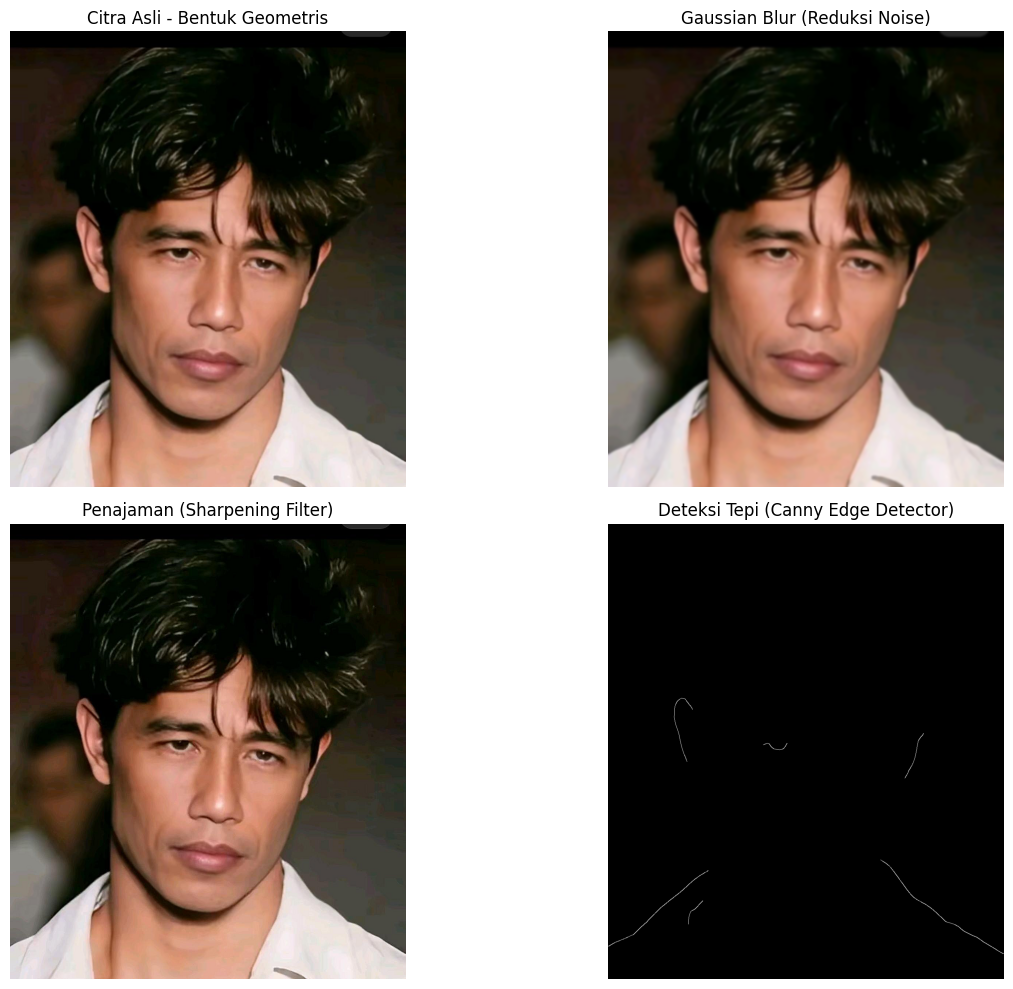

In [20]:
# Gaussian Blur (reduksi noise)
blur = cv2.GaussianBlur(img, (15, 15), 0)
blur_rgb = cv2.cvtColor(blur, cv2.COLOR_BGR2RGB)

# Sharpening (penajaman)
kernel_sharp = np.array([[0, -1, 0],
                         [-1, 5, -1],
                         [0, -1, 0]])
sharp = cv2.filter2D(img, -1, kernel_sharp)
sharp_rgb = cv2.cvtColor(sharp, cv2.COLOR_BGR2RGB)

# Deteksi tepi menggunakan Canny
edges = cv2.Canny(blur, 100, 200)

# Susun canvas 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Citra Asli
axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title("Citra Asli - Bentuk Geometris", fontsize=12)
axes[0, 0].axis("off")

# 2. Gaussian Blur
axes[0, 1].imshow(blur_rgb)
axes[0, 1].set_title("Gaussian Blur (Reduksi Noise)", fontsize=12)
axes[0, 1].axis("off")

# 3. Sharpening
axes[1, 0].imshow(sharp_rgb)
axes[1, 0].set_title("Penajaman (Sharpening Filter)", fontsize=12)
axes[1, 0].axis("off")

# 4. Deteksi Tepi Canny
axes[1, 1].imshow(edges, cmap='gray')
axes[1, 1].set_title("Deteksi Tepi (Canny Edge Detector)", fontsize=12)
axes[1, 1].axis("off")

# layout
plt.tight_layout()
plt.show()


### **Penjelasan Filter Spatial**

**Gaussian Blur (`cv2.GaussianBlur`)**:
- Parameter `(15, 15)` adalah ukuran kernel blur
- Semakin besar kernel, semakin blur hasilnya
- Berguna untuk mengurangi noise sebelum deteksi tepi

**Sharpening Filter**:
- Menggunakan kernel `[[0,-1,0], [-1,5,-1], [0,-1,0]]`
- Nilai tengah (5) memperkuat piksel pusat
- Nilai negatif (-1) mengurangi piksel sekitar
- Hasilnya: kontras tepi meningkat

**Canny Edge Detection**:
- Parameter `(100, 200)` adalah threshold rendah dan tinggi
- Piksel dengan gradien > 200 pasti tepi
- Piksel dengan gradien < 100 pasti bukan tepi
- Piksel di antara 100-200 diperiksa koneksinya

### **Menerapkan Canny dengan Threshold Berbeda**

Threshold Canny menentukan sensitivitas deteksi tepi:
- **Threshold rendah (30, 90)**: Sensitif, mendeteksi banyak tepi termasuk noise
- **Threshold sedang (50, 150)**: Seimbang antara detail dan noise
- **Threshold tinggi (100, 200)**: Ketat, hanya tepi kuat yang terdeteksi

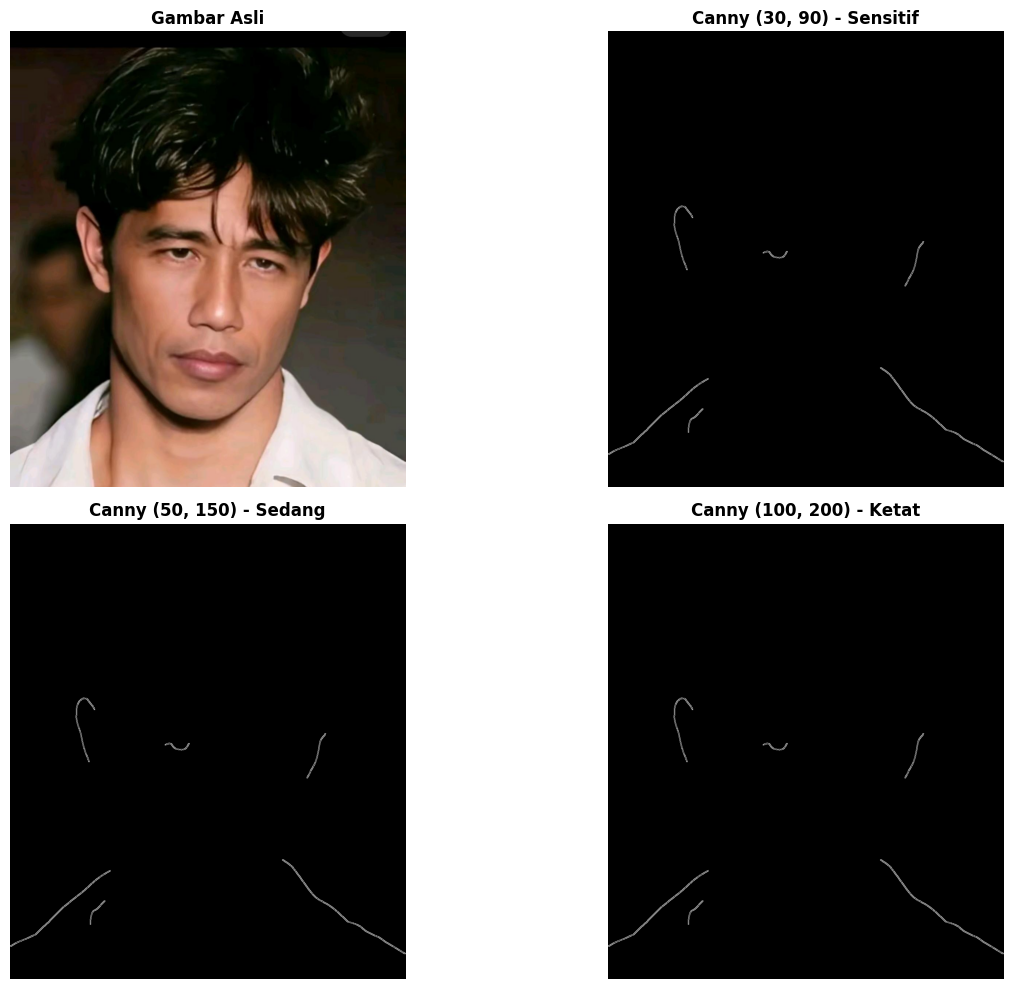

In [21]:
# Preprocessing
img_blur = cv2.GaussianBlur(edges, (5, 5), 0)

# Deteksi tepi Canny dengan berbagai threshold
edges_low = cv2.Canny(img_blur, 30, 90)     
edges_mid = cv2.Canny(img_blur, 50, 150)     
edges_high = cv2.Canny(img_blur, 100, 200)   

# Visualisasi hasil Canny
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title("Gambar Asli", fontsize=12, fontweight='bold')
axes[0, 0].axis("off")

axes[0, 1].imshow(edges_low, cmap='gray')
axes[0, 1].set_title("Canny (30, 90) - Sensitif", fontsize=12, fontweight='bold')
axes[0, 1].axis("off")

axes[1, 0].imshow(edges_mid, cmap='gray')
axes[1, 0].set_title("Canny (50, 150) - Sedang", fontsize=12, fontweight='bold')
axes[1, 0].axis("off")

axes[1, 1].imshow(edges_high, cmap='gray')
axes[1, 1].set_title("Canny (100, 200) - Ketat", fontsize=12, fontweight='bold')
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

### **Tips memilih threshold:**
- Gambar ber-noise tinggi → gunakan threshold tinggi
- Butuh detail halus → gunakan threshold rendah
- Untuk deteksi kontur → pilih threshold sedang

### **Deteksi Kontur**

**Kontur** adalah kurva yang menghubungkan titik-titik kontinu dengan intensitas warna yang sama. Dalam pengolahan citra, kontur sering digunakan untuk mendeteksi bentuk, ukuran, dan lokasi objek.

Langkah-langkah deteksi kontur:
- **Preprocessing**: Menggunakan Gaussian blur untuk mengurangi noise dan Canny edge detection untuk menemukan tepi.
- **Kontur eksternal**: Menggunakan `cv2.findContours` untuk mendeteksi hanya kontur luar.
- **Filter area**: Menyaring kontur berdasarkan ukuran untuk menghilangkan noise kecil atau objek yang tidak relevan.

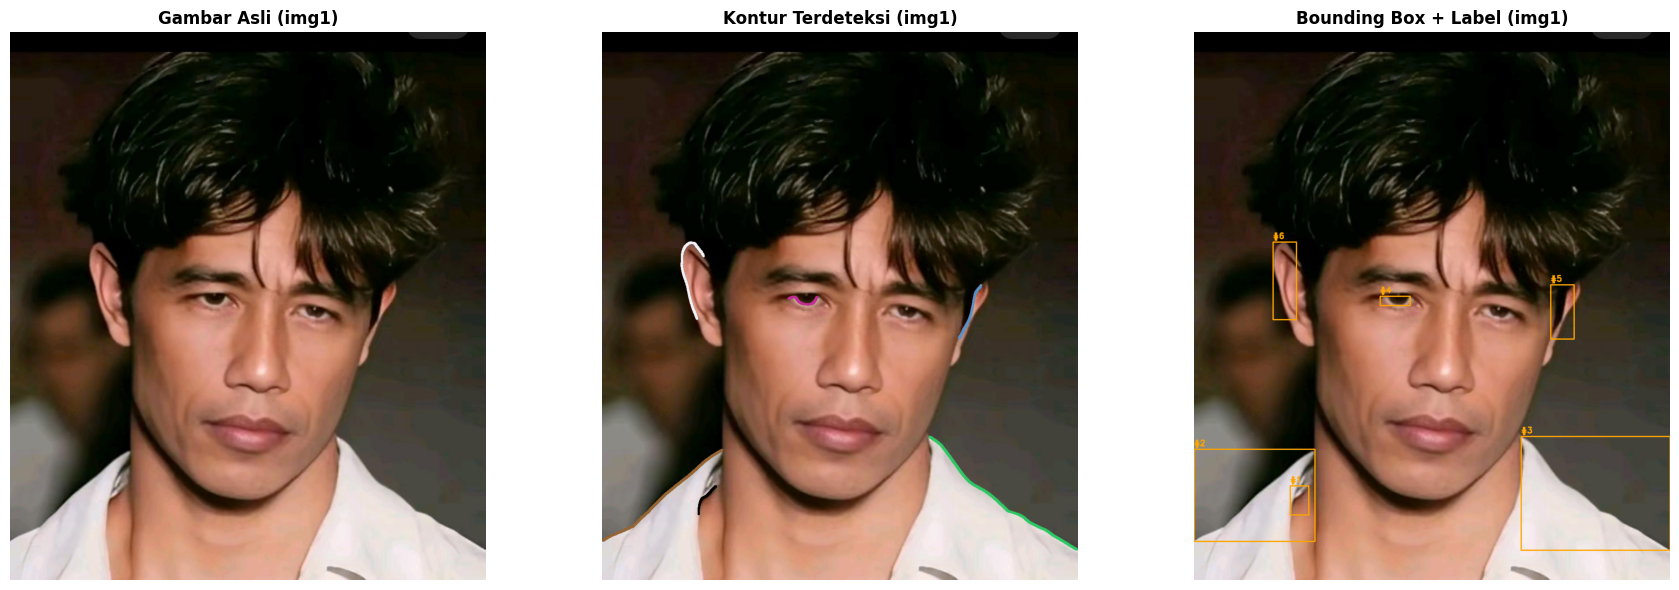

In [22]:
# Deteksi kontur menggunakan cv2.findContours pada img1
contours_img1, hierarchy_img1 = cv2.findContours(edges_mid, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Gambar 1: Kontur dengan warna berbeda
img1_contours = img.copy()
for idx, c in enumerate(contours_img1):
    # Warna berbeda untuk tiap objek
    color = (
        int((idx * 50) % 255),
        int((idx * 100) % 255),
        int((idx * 150) % 255)
    )
    cv2.drawContours(img1_contours, [c], -1, color, 2)

# Gambar 2: Bounding Box
img1_boxes = img.copy()
for idx, c in enumerate(contours_img1):
    # Hitung bounding box
    x, y, w, h = cv2.boundingRect(c)
    area = cv2.contourArea(c)
    
    # Warna berdasarkan ukuran
    if area > 5000:
        color = (255, 0, 0)  # Biru untuk objek besar
        thickness = 3
    elif area > 2000:
        color = (0, 255, 0)  # Hijau untuk objek sedang
        thickness = 2
    else:
        color = (0, 165, 255)  # Orange untuk objek kecil
        thickness = 2
    
    # Gambar rectangle
    cv2.rectangle(img1_boxes, (x, y), (x + w, y + h), color, thickness)
    
    # Tambahkan label
    label = f"#{idx+1}"
    cv2.putText(img1_boxes, label, (x, y-8), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

# Visualisasi hasil
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Gambar Asli (img1)", fontsize=12, fontweight='bold')
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(img1_contours, cv2.COLOR_BGR2RGB))
axes[1].set_title("Kontur Terdeteksi (img1)", fontsize=12, fontweight='bold')
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(img1_boxes, cv2.COLOR_BGR2RGB))
axes[2].set_title("Bounding Box + Label (img1)", fontsize=12, fontweight='bold')
axes[2].axis("off")

plt.tight_layout()
plt.show()

### **Penjelasan**

**Parameter `cv2.findContours()`:**
- **Input**: Gambar biner (hasil Canny)
- `cv2.RETR_EXTERNAL`: Hanya kontur luar (tidak ada kontur di dalam kontur)
- `cv2.CHAIN_APPROX_SIMPLE`: Menyimpan hanya titik ujung garis

**Proses filtering:**
1. Hitung area setiap kontur dengan `cv2.contourArea()`
2. Filter berdasarkan area minimum (hilangkan noise kecil)
3. Filter berdasarkan area maksimum (hilangkan frame gambar)
4. Urutkan dari area terbesar ke terkecil

**Visualisasi hasil:**
- Kontur digambar dengan warna hijau
- Setiap objek memiliki bounding box berwarna berbeda
- Label nomor menunjukkan urutan berdasarkan ukuran

In [23]:
# Muat gambar
desk_img_path = user_img_path
img2 = cv2.imread(desk_img_path)

# Ke grayscale
desk_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

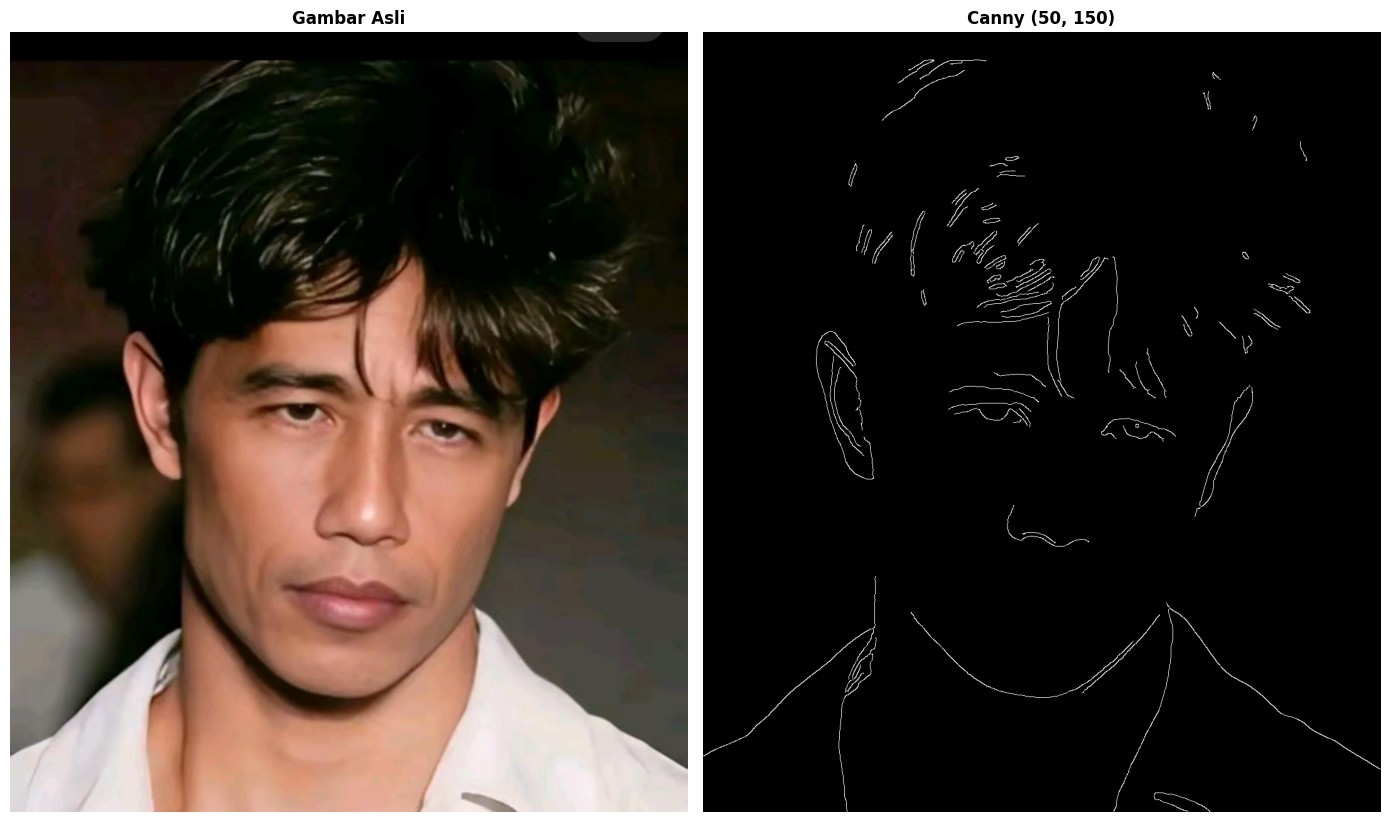

In [24]:
# Preprocessing
desk_blur = cv2.GaussianBlur(desk_gray, (5, 5), 0)

# Deteksi tepi Canny
edges = cv2.Canny(desk_blur, 50, 150)

# Visualisasi hasil Canny
fig, axes = plt.subplots(1, 2, figsize=(14, 10))

axes[0].imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
axes[0].set_title("Gambar Asli", fontsize=12, fontweight='bold')
axes[0].axis("off")

axes[1].imshow(edges, cmap='gray')
axes[1].set_title("Canny (50, 150)", fontsize=12, fontweight='bold')
axes[1].axis("off")

plt.tight_layout()
plt.show()

HANDS-ON 2: DETEKSI KONTUR DENGAN cv2.findContours
Total kontur terdeteksi: 55
Kontur setelah filter area: 18


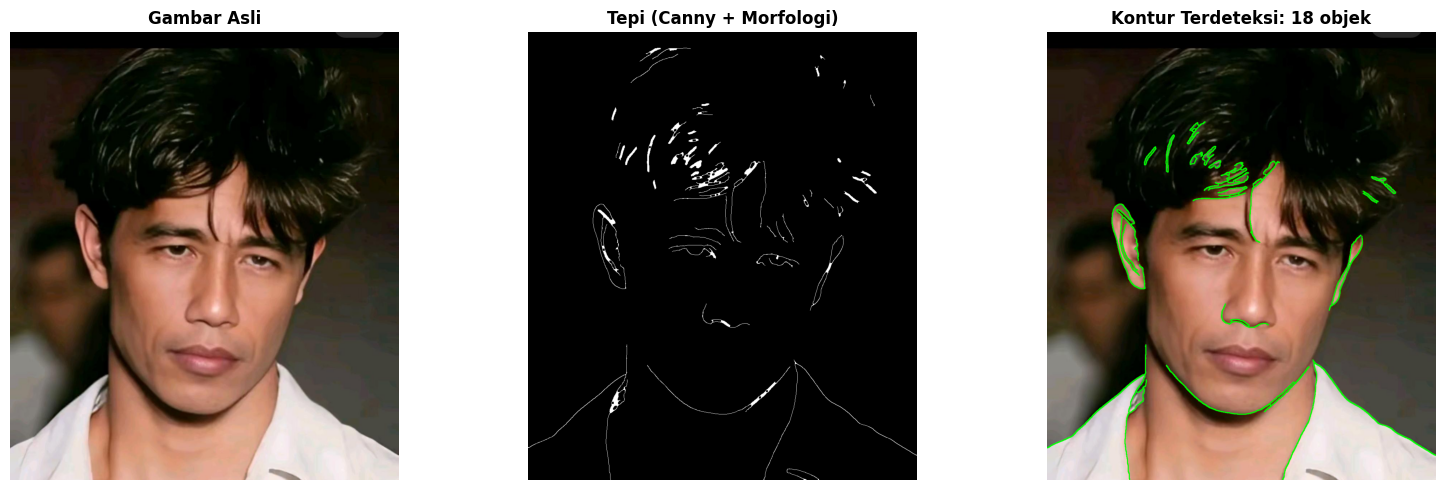

✓ Deteksi kontur berhasil



In [25]:
print("="*60)
print("HANDS-ON 2: DETEKSI KONTUR DENGAN cv2.findContours")
print("="*60)

# Gunakan edges dari Canny
edges = cv2.Canny(desk_blur, 50, 150)

# Morfologi untuk memperbaiki tepi
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
edges_closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=2)

# Deteksi kontur
contours, hierarchy = cv2.findContours(edges_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

print(f"Total kontur terdeteksi: {len(contours)}")

# Filter kontur berdasarkan area
min_area = 200
max_area = desk_gray.shape[0] * desk_gray.shape[1] * 0.8

filtered_contours = []
for c in contours:
    area = cv2.contourArea(c)
    if min_area < area < max_area:
        filtered_contours.append(c)

print(f"Kontur setelah filter area: {len(filtered_contours)}")

# Urutkan berdasarkan area (terbesar dulu)
filtered_contours = sorted(filtered_contours, key=cv2.contourArea, reverse=True)

# Visualisasi kontur
img_contours = img2.copy()
cv2.drawContours(img_contours, filtered_contours, -1, (0, 255, 0), 2)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
axes[0].set_title("Gambar Asli", fontsize=12, fontweight='bold')
axes[0].axis("off")

axes[1].imshow(edges_closed, cmap='gray')
axes[1].set_title("Tepi (Canny + Morfologi)", fontsize=12, fontweight='bold')
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(img_contours, cv2.COLOR_BGR2RGB))
axes[2].set_title(f"Kontur Terdeteksi: {len(filtered_contours)} objek", fontsize=12, fontweight='bold')
axes[2].axis("off")

plt.tight_layout()
plt.show()

print("✓ Deteksi kontur berhasil")
print()

### **Penjelasan Sistem Anotasi**

**Tiga jenis anotasi:**

1. **Kontur Warna-warni:**
   - Setiap objek diberi warna berbeda
   - Warna dihitung berdasarkan indeks objek
   - Memudahkan membedakan objek yang berdekatan

2. **Bounding Box + Label:**
   - Kotak pembatas menunjukkan area objek
   - Warna berdasarkan ukuran: biru (besar), hijau (sedang), orange (kecil)
   - Label nomor untuk identifikasi

3. **Kombinasi Lengkap:**
   - Kontur + bounding box + informasi area
   - Memberikan informasi paling lengkap
   - Berguna untuk analisis detail

**Fungsi OpenCV yang digunakan:**
- `cv2.rectangle()`: Menggambar kotak
- `cv2.putText()`: Menambah teks label
- `cv2.contourArea()`: Menghitung luas area
- `cv2.boundingRect()`: Koordinat kotak pembatas

HANDS-ON 3: ANOTASI OBJEK (KONTUR + BOUNDING BOX)


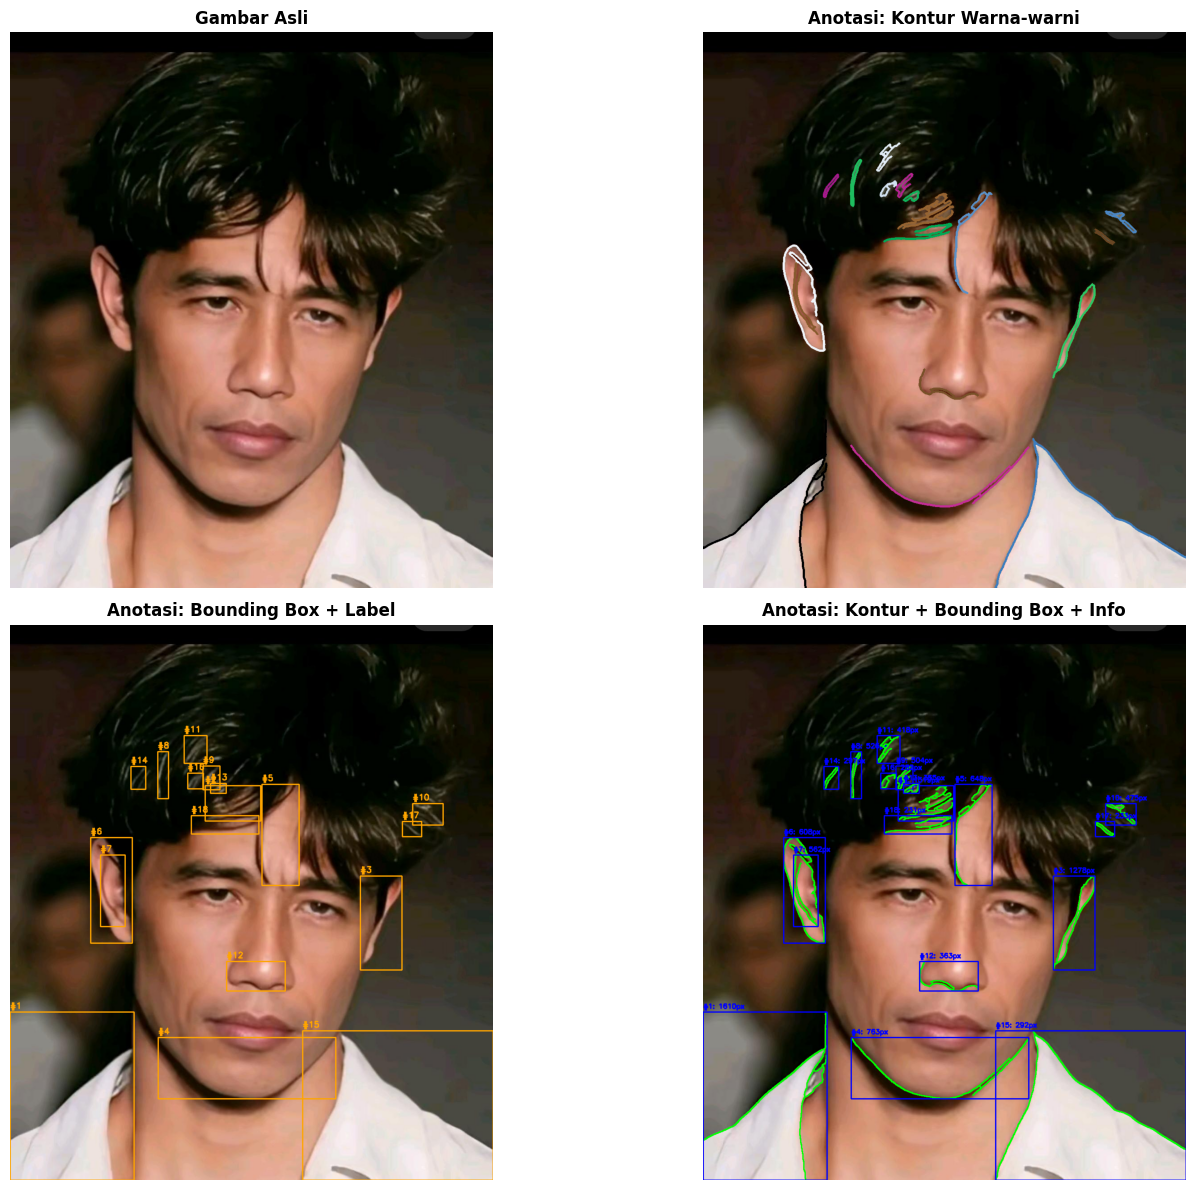

✓ Anotasi objek berhasil

STATISTIK HASIL DETEKSI OBJEK
Total objek terdeteksi: 18

Detail 10 objek terbesar:
No    Area (px)    Ukuran (WxH)    Posisi (x,y)   
------------------------------------------------------------
1     1610         277x376          (0,867)
2     1519         124x79           (436,361)
3     1278         93x210          (783,563)
4     763          397x137          (331,924)
5     648          83x226          (563,358)
6     608          93x236          (180,477)
7     562          55x160          (202,516)
8     526          24x105          (330,285)
9     504          38x53           (431,317)
10    475          68x48           (900,401)

... dan 8 objek lainnya


In [26]:
print("="*60)
print("HANDS-ON 3: ANOTASI OBJEK (KONTUR + BOUNDING BOX)")
print("="*60)

# Gambar 1: Kontur dengan warna berbeda
img_annotated_contours = img2.copy()
for idx, c in enumerate(filtered_contours):
    # Warna berbeda untuk tiap objek
    color = (
        int((idx * 50) % 255),
        int((idx * 100) % 255),
        int((idx * 150) % 255)
    )
    cv2.drawContours(img_annotated_contours, [c], -1, color, 3)

# Gambar 2: Bounding Box
img_annotated_boxes = img2.copy()
for idx, c in enumerate(filtered_contours):
    # Hitung bounding box
    x, y, w, h = cv2.boundingRect(c)
    area = cv2.contourArea(c)
    
    # Warna berdasarkan ukuran
    if area > 5000:
        color = (255, 0, 0)  # Biru untuk objek besar
        thickness = 3
    elif area > 2000:
        color = (0, 255, 0)  # Hijau untuk objek sedang
        thickness = 2
    else:
        color = (0, 165, 255)  # Orange untuk objek kecil
        thickness = 2
    
    # Gambar rectangle
    cv2.rectangle(img_annotated_boxes, (x, y), (x + w, y + h), color, thickness)
    
    # Tambahkan label
    label = f"#{idx+1}"
    cv2.putText(img_annotated_boxes, label, (x, y-8), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

# Gambar 3: Kombinasi kontur + bounding box + info
img_annotated_full = img2.copy()
for idx, c in enumerate(filtered_contours):
    x, y, w, h = cv2.boundingRect(c)
    area = cv2.contourArea(c)
    
    # Gambar kontur
    cv2.drawContours(img_annotated_full, [c], -1, (0, 255, 0), 2)
    
    # Gambar bounding box
    cv2.rectangle(img_annotated_full, (x, y), (x + w, y + h), (255, 0, 0), 2)
    
    # Label detail
    label = f"#{idx+1}: {int(area)}px"
    cv2.putText(img_annotated_full, label, (x, y-8), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

# Visualisasi anotasi
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title("Gambar Asli", fontsize=12, fontweight='bold')
axes[0, 0].axis("off")

axes[0, 1].imshow(cv2.cvtColor(img_annotated_contours, cv2.COLOR_BGR2RGB))
axes[0, 1].set_title("Anotasi: Kontur Warna-warni", fontsize=12, fontweight='bold')
axes[0, 1].axis("off")

axes[1, 0].imshow(cv2.cvtColor(img_annotated_boxes, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title("Anotasi: Bounding Box + Label", fontsize=12, fontweight='bold')
axes[1, 0].axis("off")

axes[1, 1].imshow(cv2.cvtColor(img_annotated_full, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title("Anotasi: Kontur + Bounding Box + Info", fontsize=12, fontweight='bold')
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

print("✓ Anotasi objek berhasil")
print()

print("="*60)
print("STATISTIK HASIL DETEKSI OBJEK")
print("="*60)
print(f"Total objek terdeteksi: {len(filtered_contours)}")
print(f"\nDetail 10 objek terbesar:")
print(f"{'No':<5} {'Area (px)':<12} {'Ukuran (WxH)':<15} {'Posisi (x,y)':<15}")
print("-"*60)

for idx, c in enumerate(filtered_contours[:10]):
    area = cv2.contourArea(c)
    x, y, w, h = cv2.boundingRect(c)
    print(f"{idx+1:<5} {int(area):<12} {w}x{h:<12} ({x},{y})")

if len(filtered_contours) > 10:
    print(f"\n... dan {len(filtered_contours)-10} objek lainnya")

print("="*60)

> **Pertanyaan:** Bagaimana mengoptimalkan kontur agar terdeteksi hanya 4 objek?

## **Deteksi Wajah dengan Haar Cascades**

**Haar Cascade** adalah metode machine learning untuk deteksi objek yang dikembangkan oleh Paul Viola dan Michael Jones. Karakteristik utama:

- Menggunakan **fitur Haar-like** (pola terang-gelap sederhana)
- **Cascade classifier**: Serangkaian classifier lemah yang digabung
- **Cepat**: Dapat berjalan real-time pada webcam
- **Pre-trained**: OpenCV menyediakan model siap pakai

**Keunggulan:**
- Tidak perlu training data sendiri
- Akurasi cukup baik untuk wajah frontal
- Komputasi ringan

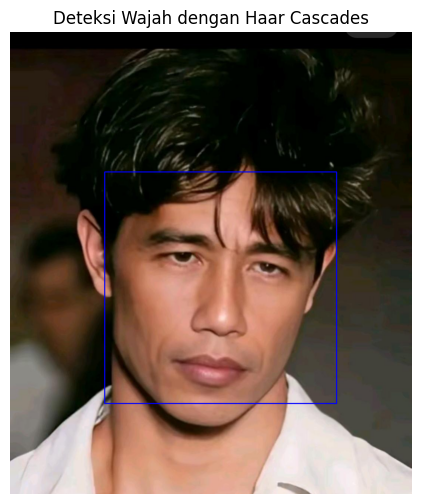

In [27]:
# Load the pre-trained Haar Cascade for face detection
haar_cascade_path = os.path.join(cv2.data.haarcascades, 'haarcascade_frontalface_default.xml')
face_cascade = cv2.CascadeClassifier(haar_cascade_path)

# Load the image
face_path = user_img_path
img3 = cv2.imread(face_path)

# Convert the image to grayscale (Haar Cascades work on grayscale images)
gray_face_image = cv2.cvtColor(img3, cv2.COLOR_BGR2GRAY)

# Detect faces in the image
faces = face_cascade.detectMultiScale(gray_face_image, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

# Draw rectangles around detected faces
for (x, y, w, h) in faces:
    cv2.rectangle(img3, (x, y), (x + w, y + h), (255, 0, 0), 2)

# Convert the image to RGB for displaying with matplotlib
image_rgb = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)

# Display the result
plt.figure(figsize=(10, 6))
plt.imshow(image_rgb)
plt.title("Deteksi Wajah dengan Haar Cascades")
plt.axis("off")
plt.show()

### **XML Pra Terlatih OpenCV**

OpenCV menyediakan berbagai model Haar Cascade:
- `haarcascade_frontalface_default.xml`: Wajah tampak depan
- `haarcascade_eye.xml`: Mata
- `haarcascade_smile.xml`: Senyuman
- `haarcascade_profileface.xml`: Wajah profil

File XML berisi ribuan fitur yang sudah dilatih pada jutaan gambar positif dan negatif.

In [28]:
print("="*60)
print("HANDS-ON 4: PERBANDINGAN HAAR CASCADE DENGAN PARAMETER BERBEDA")
print("="*60)

# Load the pre-trained Haar Cascade for face detection
haar_cascade_path = os.path.join(cv2.data.haarcascades, 'haarcascade_frontalface_default.xml')
face_cascade = cv2.CascadeClassifier(haar_cascade_path)

# Load the image
many_face_path = user_img_path
img_original = cv2.imread(many_face_path)

# Buat copy terpisah untuk setiap metode
img_haar = img_original.copy()
img_dlib = img_original.copy()

# Convert to grayscale for processing
gray_faces = cv2.cvtColor(img_original, cv2.COLOR_BGR2GRAY)

print(f"Ukuran gambar: {img_original.shape}")
print("Memproses deteksi wajah...")


HANDS-ON 4: PERBANDINGAN HAAR CASCADE DENGAN PARAMETER BERBEDA
Ukuran gambar: (1243, 1080, 3)
Memproses deteksi wajah...


In [29]:
# ========================================
# METODE 1: HAAR CASCADE
# ========================================

# Detect faces using Haar Cascade
faces_haar = face_cascade.detectMultiScale(
    gray_faces, 
    scaleFactor=1.1, 
    minNeighbors=5, 
    minSize=(30, 30)
)

# Draw rectangles and labels for Haar Cascade
for idx, (x, y, w, h) in enumerate(faces_haar):
    # Gambar kotak biru untuk Haar Cascade
    cv2.rectangle(img_haar, (x, y), (x + w, y + h), (255, 0, 0), 3)
    
    # Label dengan nomor urut
    label = f"Wajah #{idx+1}"
    cv2.putText(img_haar, label, (x, y - 10), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

print(f"Haar Cascade mendeteksi: {len(faces_haar)} wajah")
if len(faces_haar) > 0:
    print("Detail deteksi Haar Cascade:")
    for idx, (x, y, w, h) in enumerate(faces_haar):
        print(f"  Wajah #{idx+1}: posisi ({x},{y}), ukuran {w}x{h}")

Haar Cascade mendeteksi: 1 wajah
Detail deteksi Haar Cascade:
  Wajah #1: posisi (254,376), ukuran 623x623


### **dlib: Deteksi Wajah Berbasis HOG dan CNN**

**dlib** adalah pustaka machine learning yang menyediakan berbagai algoritma untuk pengolahan citra dan visi komputer. Dalam konteks deteksi wajah, dlib menawarkan dua metode utama:

1. **Histogram of Oriented Gradients (HOG)**:
    - Menggunakan fitur gradien arah untuk mendeteksi wajah.
    - Cepat dan ringan, cocok untuk aplikasi real-time.
    - Akurasi baik untuk wajah frontal, tetapi kurang optimal untuk wajah dengan sudut miring.

2. **Convolutional Neural Network (CNN)**:
    - Menggunakan model deep learning untuk deteksi wajah.
    - Lebih akurat dibandingkan HOG, terutama untuk wajah dengan berbagai orientasi.
    - Membutuhkan lebih banyak sumber daya komputasi.

**Keunggulan dlib**:
- Tidak memerlukan file XML seperti Haar Cascade.
- Deteksi lebih akurat dan fleksibel dibandingkan metode tradisional.
- Mendukung deteksi landmark wajah untuk analisis lebih lanjut (misalnya, pelacakan ekspresi).

In [30]:
# ========================================
# METODE 2: HAAR CASCADE ALTERNATIF (PENGGANTI DLIB)
# ========================================
# Karena beberapa komputer Windows sering error saat install dlib,
# bagian ini diganti dengan Haar Cascade parameter berbeda agar tetap menghasilkan citra output.

faces_dlib = face_cascade.detectMultiScale(
    gray_faces,
    scaleFactor=1.05,
    minNeighbors=3,
    minSize=(25, 25)
)

for idx, (x, y, w, h) in enumerate(faces_dlib):
    cv2.rectangle(img_dlib, (x, y), (x + w, y + h), (0, 255, 0), 3)
    label = f"Wajah alt #{idx+1}"
    cv2.putText(img_dlib, label, (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

print(f"Haar alternatif mendeteksi: {len(faces_dlib)} wajah")
if len(faces_dlib) > 0:
    print('Detail deteksi Haar alternatif:')
    for idx, (x, y, w, h) in enumerate(faces_dlib):
        print(f"  Wajah alt #{idx+1}: posisi ({x},{y}), ukuran {w}x{h}")


Haar alternatif mendeteksi: 1 wajah
Detail deteksi Haar alternatif:
  Wajah alt #1: posisi (266,380), ukuran 598x598


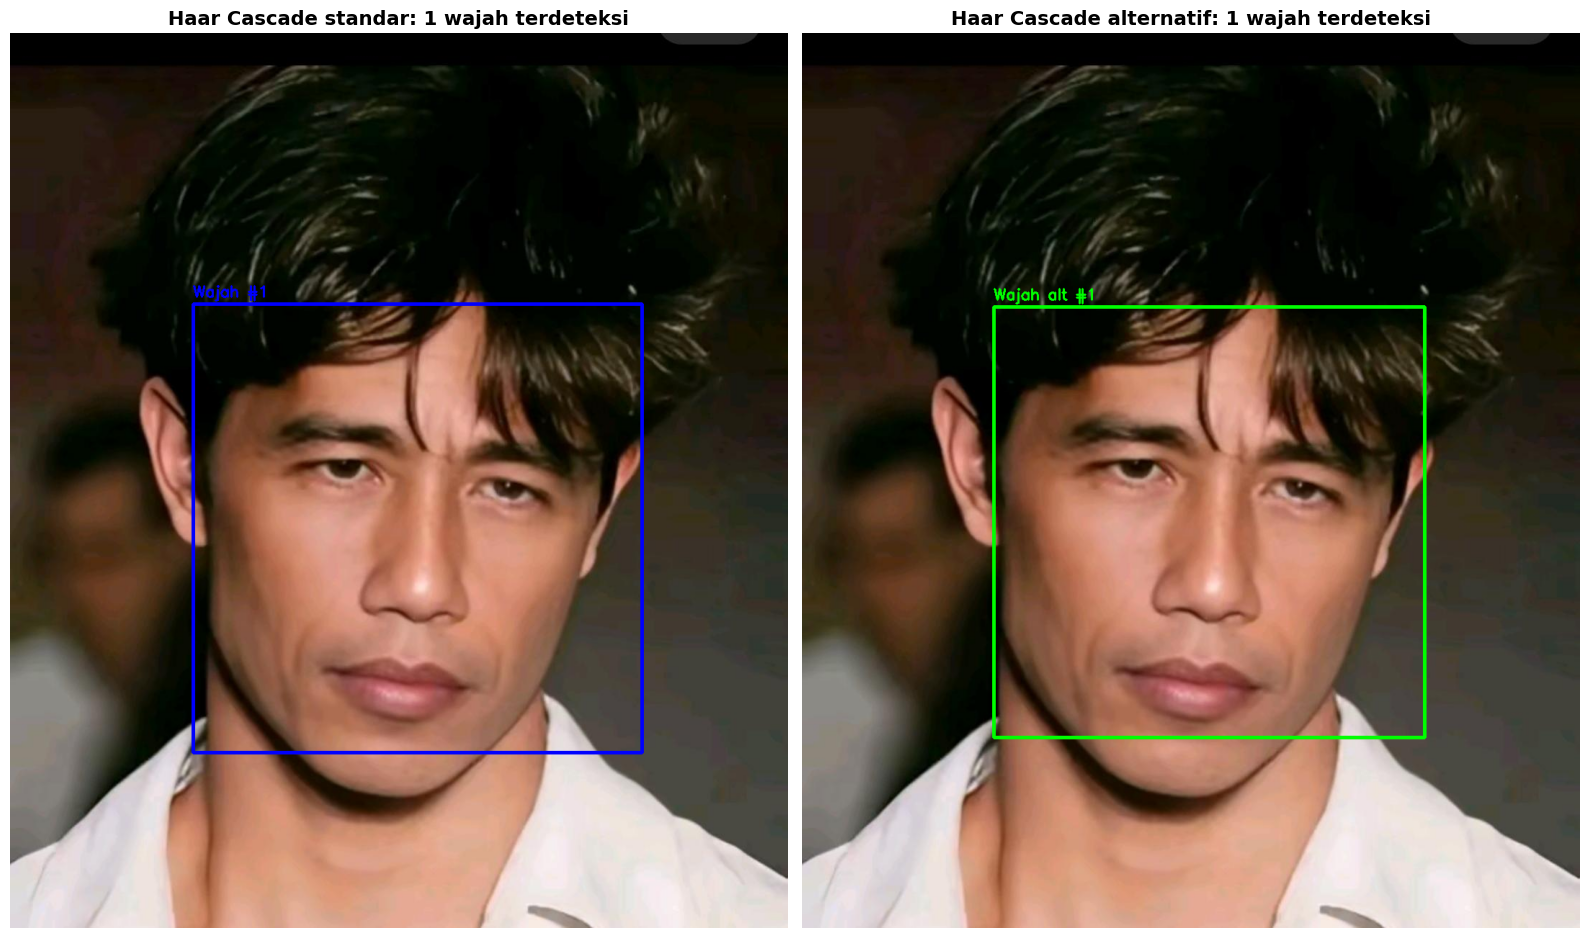


ANALISIS PERBANDINGAN HAAR CASCADE
• Haar standar     : 1 wajah
• Haar alternatif  : 1 wajah
Catatan: bagian dlib diganti supaya notebook tidak error ketika library dlib belum terinstall.


In [31]:
# ========================================
# VISUALISASI PERBANDINGAN
# ========================================

# Convert images to RGB for matplotlib display
img_original_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
img_haar_rgb = cv2.cvtColor(img_haar, cv2.COLOR_BGR2RGB)
img_alt_rgb = cv2.cvtColor(img_dlib, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(16, 12))

axes[0].imshow(img_haar_rgb)
axes[0].set_title(f"Haar Cascade standar: {len(faces_haar)} wajah terdeteksi", 
                  fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img_alt_rgb)
axes[1].set_title(f"Haar Cascade alternatif: {len(faces_dlib)} wajah terdeteksi", 
                  fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print('\n' + '='*60)
print('ANALISIS PERBANDINGAN HAAR CASCADE')
print('='*60)
print(f'• Haar standar     : {len(faces_haar)} wajah')
print(f'• Haar alternatif  : {len(faces_dlib)} wajah')
print('Catatan: bagian dlib diganti supaya notebook tidak error ketika library dlib belum terinstall.')


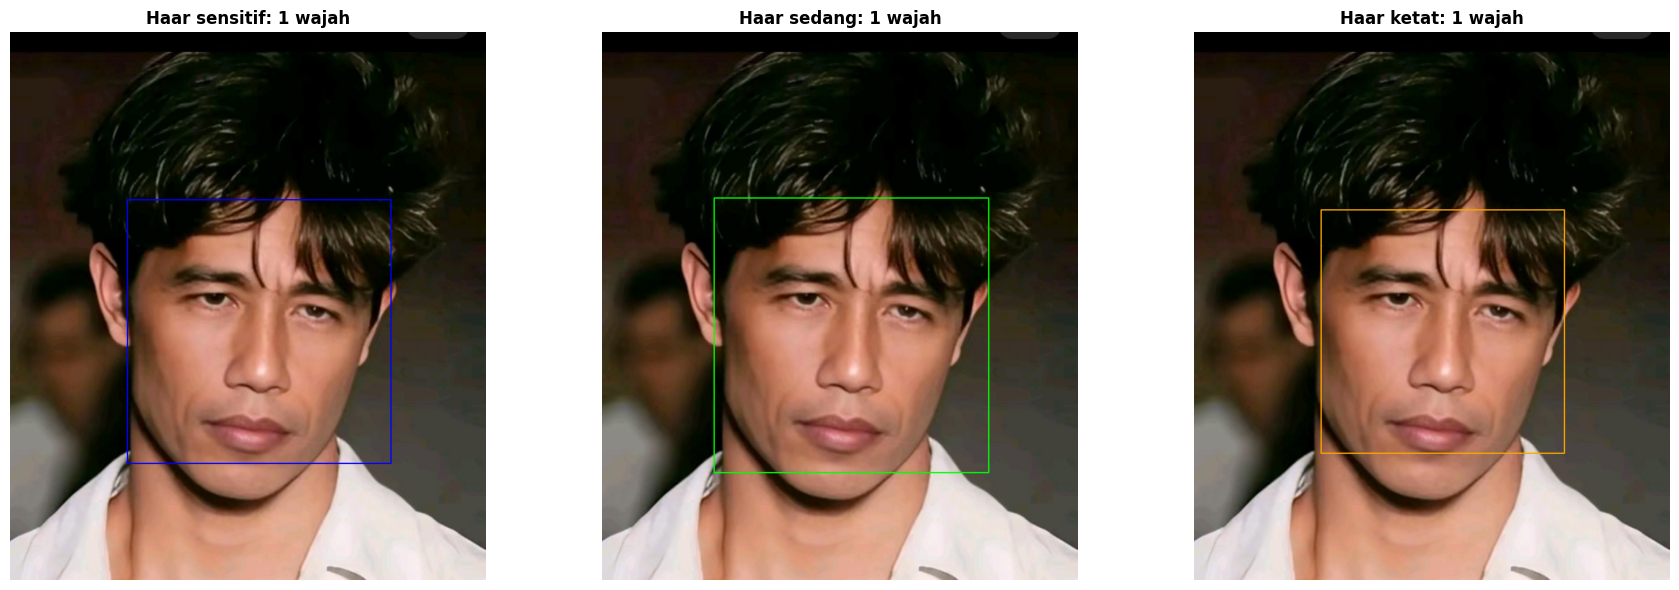

In [32]:
# Perbandingan 3 variasi Haar Cascade pada gambar user
multiple2_path = user_img_path
img_multiple2 = cv2.imread(multiple2_path)
gray_multiple2 = cv2.cvtColor(img_multiple2, cv2.COLOR_BGR2GRAY)

configs = [
    ('Haar sensitif', 1.05, 3, (255, 0, 0)),
    ('Haar sedang', 1.10, 5, (0, 255, 0)),
    ('Haar ketat', 1.20, 7, (0, 165, 255)),
]

hasil = []
for nama, scale, neighbors, color in configs:
    faces = face_cascade.detectMultiScale(
        gray_multiple2,
        scaleFactor=scale,
        minNeighbors=neighbors,
        minSize=(25, 25)
    )
    img_vis = img_multiple2.copy()
    for (x, y, w, h) in faces:
        cv2.rectangle(img_vis, (x, y), (x + w, y + h), color, 2)
    hasil.append((nama, faces, cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB)))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (nama, faces, img_rgb) in zip(axes, hasil):
    ax.imshow(img_rgb)
    ax.set_title(f"{nama}: {len(faces)} wajah", fontsize=12, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()
